In [ ]:
# Final Guided EDA Project

## Mall Customers Dataset

### Student Name:
#Shahad Abdullah

### Dataset:
#Mall Customers Dataset

### Course:
#Artificial Intelligence Bootcamp


1. What is the dataset about?

This dataset contains information about mall customers. It includes age, gender, education, marital status, annual income, and spending score.

2. What does each row represent?

Each row represents one customer.

3. How many rows and columns are there?

The dataset contains 200 rows and 7 columns.

4. How many numerical and categorical features are there?

There are 3 numerical features (Age, Annual Income, Spending Score) and 3 categorical features (Gender, Education, Marital Status). CustomerID is an identifier.

5. What is the target feature?

This is an EDA project, so there is no target feature. However, the main variable I focused on was Spending Score.



Why did you analyze this dataset?

The purpose of this analysis was to understand customer behavior and determine whether Age and Annual Income are related to Spending Score

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Mall Customers.xlsx to Mall Customers.xlsx


In [3]:


df = pd.read_excel("Mall Customers.xlsx")

In [4]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Number of Rows: 200
Number of Columns: 7

Column Names:
Index(['CustomerID', 'Gender', 'Age', 'Education ', 'Marital Status',
       'Annual Income (k$)', 'Spending Score (1-100)'],
      dtype='object')

Data Types:
CustomerID                 int64
Gender                    object
Age                        int64
Education                 object
Marital Status            object
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


In [5]:
print("First Five Rows")
display(df.head())

print("Last Five Rows")
display(df.tail())

print("Random Sample")
display(df.sample(5))

First Five Rows


,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


Last Five Rows


,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
195,196,F,35,High School,Married,120,79
196,197,F,45,High School,Unknown,126,28
197,198,M,32,Uneducated,Married,126,74
198,199,M,32,High School,Married,137,18
199,200,M,30,College,Married,137,83


Random Sample


,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
77,78,M,40,Uneducated,Single,54,48
196,197,F,45,High School,Unknown,126,28
190,191,F,34,Graduate,Married,103,23
104,105,M,49,High School,Unknown,62,56
55,56,M,47,Graduate,Unknown,43,41


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Education               200 non-null    object
 4   Marital Status          200 non-null    object
 5   Annual Income (k$)      200 non-null    int64 
 6   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 11.1+ KB


In [7]:
display(df.describe())

display(df.describe(include="object"))

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


,Gender,Education,Marital Status
count,200,200,200
unique,2,7,4
top,F,Graduate,Married
freq,112,67,112


In [8]:
# Data Quality Assessment

print("Missing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nUnique Customer IDs:")
print(df["CustomerID"].nunique())

Missing Values:


,0
CustomerID,0
Gender,0
Age,0
Education,0
Marital Status,0
Annual Income (k$),0
Spending Score (1-100),0



Duplicate Rows:
0

Unique Customer IDs:
200


In [9]:
# Check for invalid values

print("Negative Ages:")
print((df["Age"] < 0).sum())

print("\nNegative Annual Income:")
print((df["Annual Income (k$)"] < 0).sum())

print("\nSpending Score greater than 100:")
print((df["Spending Score (1-100)"] > 100).sum())

print("\nSpending Score less than 0:")
print((df["Spending Score (1-100)"] < 0).sum())

Negative Ages:
0

Negative Annual Income:
0

Spending Score greater than 100:
0

Spending Score less than 0:
0


In [11]:
# Inconsistent Categories
print("Gender:")
print(df["Gender"].unique())

print("\nEducation:")
print(df["Education "].unique())

print("\nMarital Status:")
print(df["Marital Status"].unique())

#No inconsistent category labels were found. All categorical values are written consistently, so no cleaning was required.

Gender:
['M' 'F']

Education:
['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']

Marital Status:
['Married' 'Single' 'Unknown' 'Divorced']


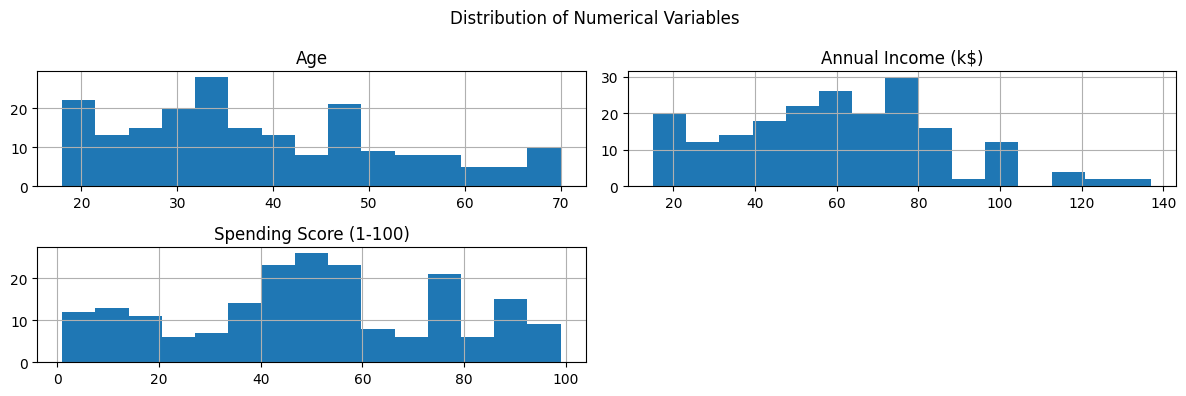

In [12]:
# Histograms for numerical variables

numerical_columns = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

df[numerical_columns].hist(figsize=(12, 4), bins=15)

plt.suptitle("Distribution of Numerical Variables")
plt.tight_layout()
plt.show()


### Histogram

**What does the chart show?**
The histogram shows the distribution of Age, Annual Income, and Spending Score.

**Conclusion**
Most customers are between 25 and 50 years old. Annual income and spending scores are spread across different ranges.

**Why is this useful?**
It helps understand the distribution of numerical variables and identify unusual patterns.

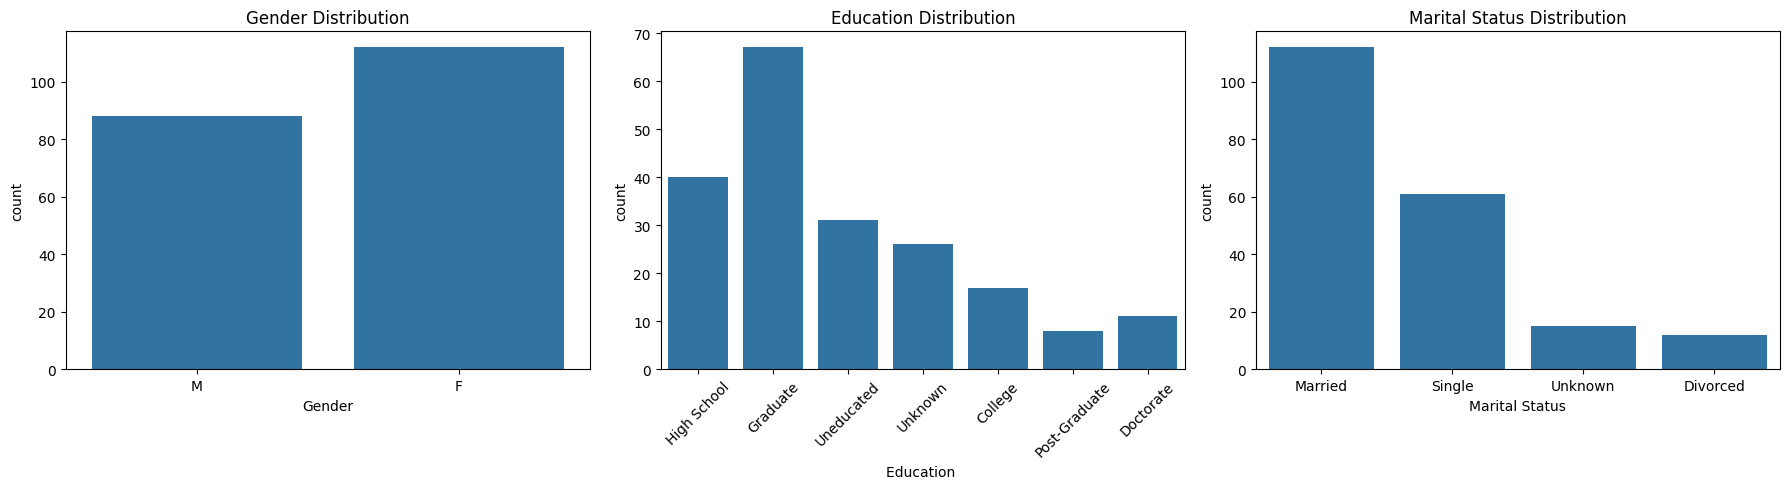

In [14]:
# Categorical variable distributions

fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.countplot(data=df, x="Gender", ax=axes[0])
axes[0].set_title("Gender Distribution")

sns.countplot(data=df, x="Education ", ax=axes[1])
axes[1].set_title("Education Distribution")
axes[1].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x="Marital Status", ax=axes[2])
axes[2].set_title("Marital Status Distribution")

plt.tight_layout()
plt.show()

### Count Plot

**What does the chart show?**
The chart shows the distribution of Gender, Education, and Marital Status.

**Conclusion**
Female customers are slightly more than male customers, and Graduate is the most common education level.

**Why is this useful?**
It helps understand customer demographics.

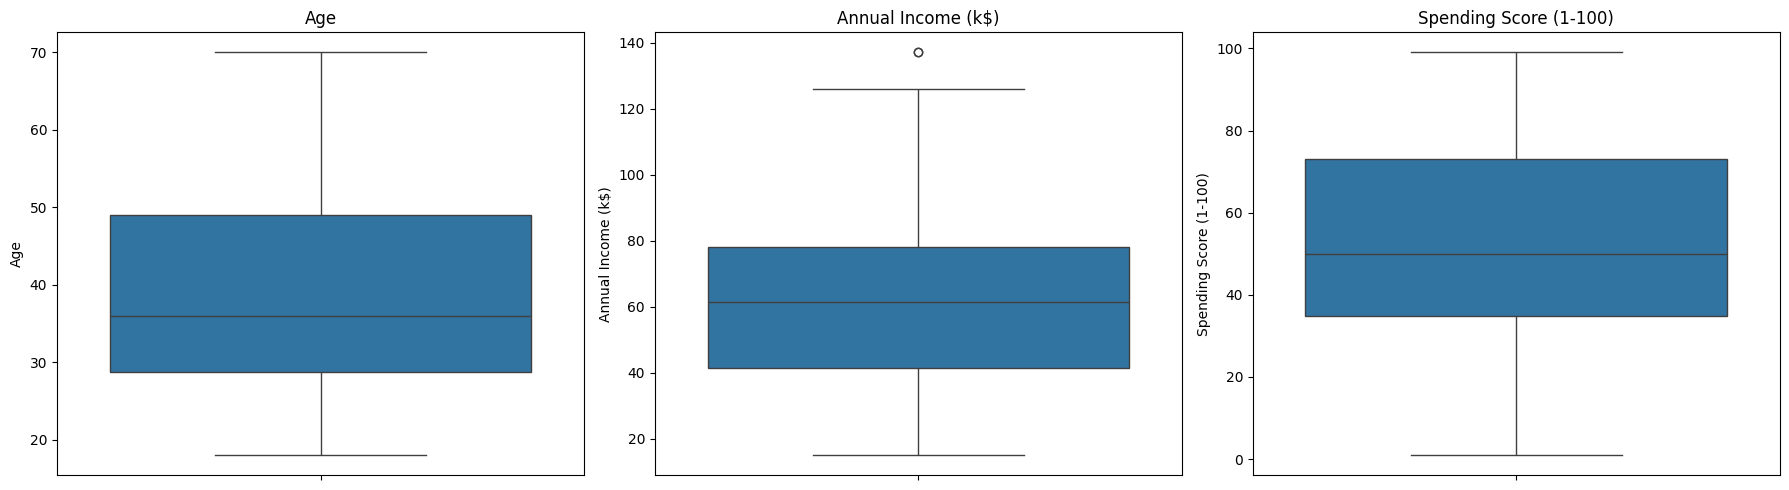

In [15]:
# Outlier Detection

fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.boxplot(data=df, y="Age", ax=axes[0])
axes[0].set_title("Age")

sns.boxplot(data=df, y="Annual Income (k$)", ax=axes[1])
axes[1].set_title("Annual Income (k$)")

sns.boxplot(data=df, y="Spending Score (1-100)", ax=axes[2])
axes[2].set_title("Spending Score (1-100)")

plt.tight_layout()
plt.show()


### Box Plot

**What does the chart show?**
The box plots summarize the distribution of Age, Annual Income, and Spending Score.

**Conclusion**
Annual Income contains two outliers, while Age and Spending Score do not contain significant outliers.

**Why is this useful?**
It helps detect unusual observations that may affect the analysis.


In [16]:
# IQR Method

numerical_columns = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}")
    print(f"Number of Outliers: {len(outliers)}")
    print("-" * 40)

Age
Number of Outliers: 0
----------------------------------------
Annual Income (k$)
Number of Outliers: 2
----------------------------------------
Spending Score (1-100)
Number of Outliers: 0
----------------------------------------


### Outlier Analysis

- Age: No outliers were detected.
- Annual Income: Two outliers were identified using the IQR method. These values appear to be realistic high-income customers rather than data entry errors, so they were kept.
- Spending Score: No outliers were detected.


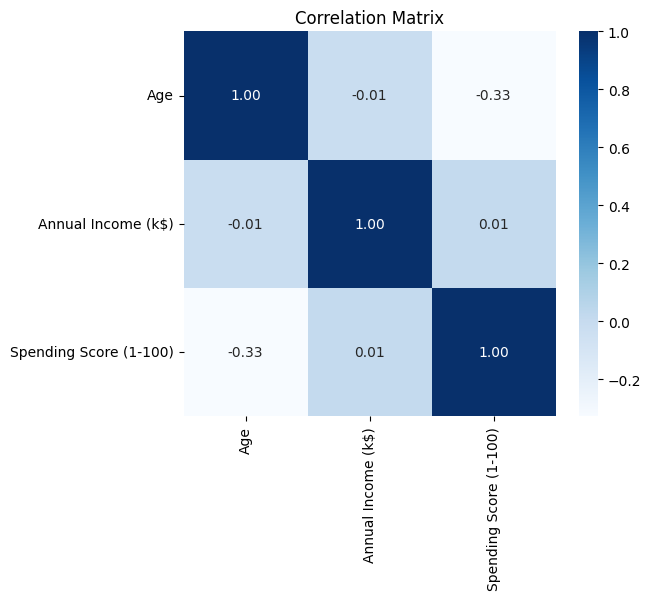

In [17]:
# Correlation Matrix

numerical_df = df[
    ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
]

plt.figure(figsize=(6,5))
sns.heatmap(
    numerical_df.corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

### Correlation Matrix

**What does the chart show?**
The heatmap shows the correlation between numerical variables.

**Conclusion**
Age has a weak negative correlation with Spending Score, while Annual Income has almost no linear relationship with Spending Score.

**Why is this useful?**
It helps identify relationships between variables.


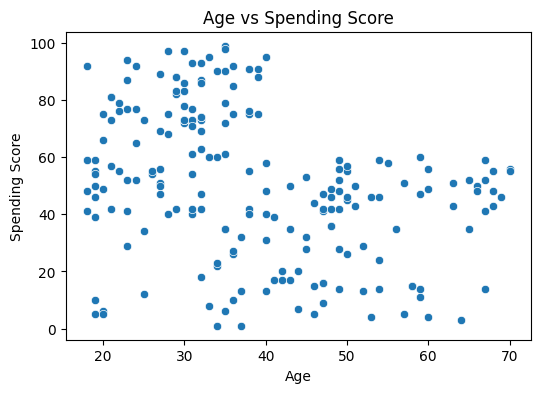

In [18]:
# Age vs Spending Score

plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df,
    x="Age",
    y="Spending Score (1-100)"
)

plt.title("Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.show()

### Scatter Plot: Age vs Spending Score

**What does the chart show?**
The scatter plot shows the relationship between customer age and spending score.

**Conclusion**
There is no strong relationship between age and spending score.

**Why is this useful?**
It helps determine whether age influences spending behavior.



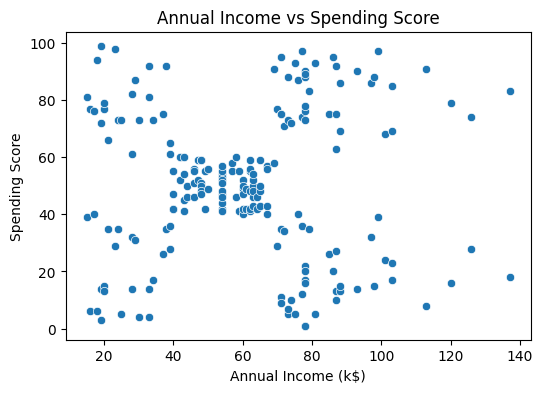

In [18]:
# Annual Income vs Spending Score

plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)"
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.show()

### Scatter Plot: Annual Income vs Spending Score

**What does the chart show?**
The chart compares annual income with spending score.

**Conclusion**
Customers with similar incomes can have different spending scores.

**Why is this useful?**
It helps understand that income alone does not explain customer spending.

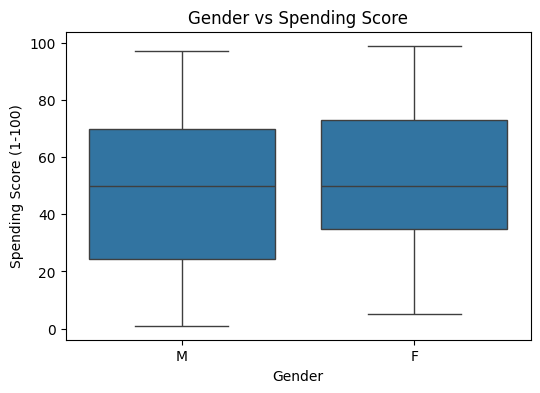

In [19]:
# Gender vs Spending Score

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Gender",
    y="Spending Score (1-100)"
)

plt.title("Gender vs Spending Score")
plt.show()

### Box Plot: Gender vs Spending Score

**What does the chart show?**
The box plot compares spending scores between male and female customers.

**Conclusion**
The spending score distributions for males and females are similar.

**Why is this useful?**
It helps compare customer spending behavior across genders.

# Key Insights

1. The dataset contains 200 customers and 7 variables.

2. No missing values were found.

3. No duplicate records were detected.

4. CustomerID is unique for every customer.

5. Annual Income contains 2 outliers according to the IQR method.

6. Female customers are slightly more than male customers.

7. Most customers are graduates.

8. Most customers are married.

9. Age has a weak negative correlation with Spending Score.

10. Annual Income has almost no linear correlation with Spending Score.

**Business Recommendations**
1. Create marketing campaigns targeting young adult customers, as they represent a large portion of the customer base.

2. Develop personalized promotions based on customer spending behavior instead of relying only on income levels.

3. Maintain high data quality by continuing to validate customer information during data entry.

4. Monitor high-income customers separately to better understand their purchasing behavior and improve marketing strategies.

5. Collect additional customer information, such as shopping frequency or product preferences, to support more accurate future analysis and machine learning models.

**Reflection**
### 1. What was the most challenging data quality problem?

The most challenging part was checking the dataset for potential outliers and determining whether they were actual observations or data errors.

### 2. Which decision required the most critical thinking?

Deciding to keep the detected income outliers because they appeared to represent real customers rather than incorrect data.

### 3. What was the most interesting finding?

The most interesting finding was that annual income has very little relationship with spending score.

### 4. If you repeated this project, what would you do differently?

I would explore additional visualization techniques and apply customer segmentation methods to gain deeper insights.

### 5. What did you learn about EDA from this project?

I learned how to inspect data quality, clean datasets, visualize data, identify patterns, and extract meaningful insights before building machine learning models.
